# Phase 6 - Exploratory Data Analysis (EDA)

## Objectives

The objective of this phase is to explore hotel booking patterns, customer behavior, cancellation trends, revenue performance, and stay characteristics using visual analytics.

### Analysis Covered

- Booking Analysis
- Customer Analysis
- Cancellation Analysis
- Revenue Analysis
- Stay Analysis

### Visualizations

- Line Charts
- Bar Charts
- Pie Charts
- Histograms
- Box Plots
- Scatter Plots
- Violin Plots
- Heatmaps
- Pair Plots

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("processed_hotel_bookings.csv")

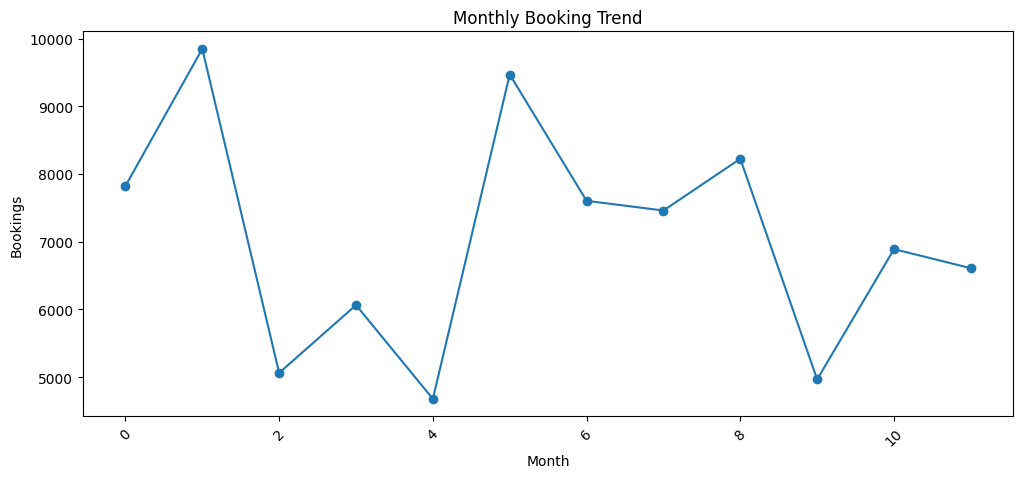

In [3]:
#Monthly Booking Trend
monthly = df.groupby("arrival_date_month").size()

plt.figure(figsize=(12,5))
monthly.plot(kind="line",marker="o")
plt.title("Monthly Booking Trend")
plt.xlabel("Month")
plt.ylabel("Bookings")
plt.xticks(rotation=45)
plt.show()

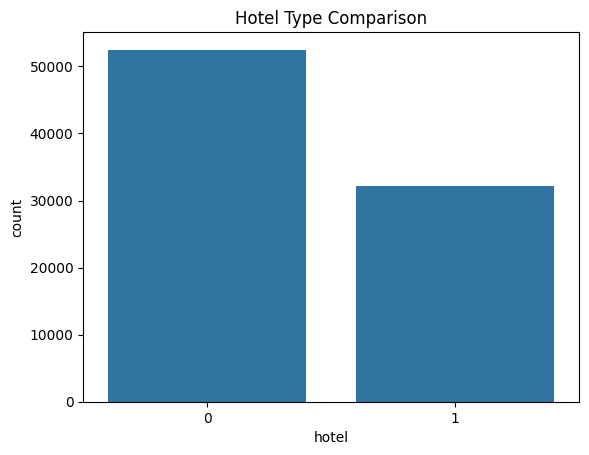

In [4]:
#Hotel Type Comparison
sns.countplot(data=df,x="hotel")
plt.title("Hotel Type Comparison")
plt.show()

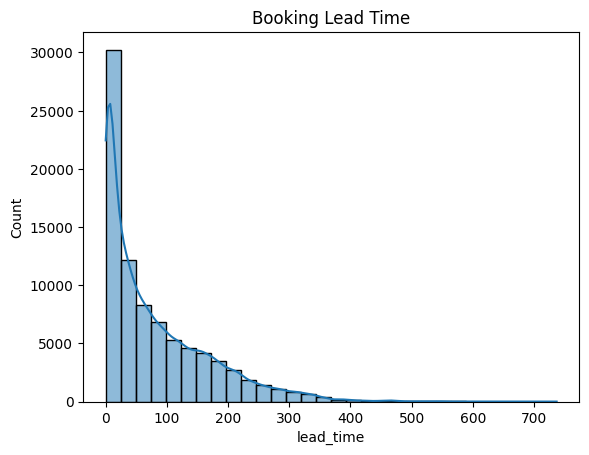

In [5]:
#Booking Lead Time
sns.histplot(df["lead_time"],bins=30,kde=True)
plt.title("Booking Lead Time")
plt.show()

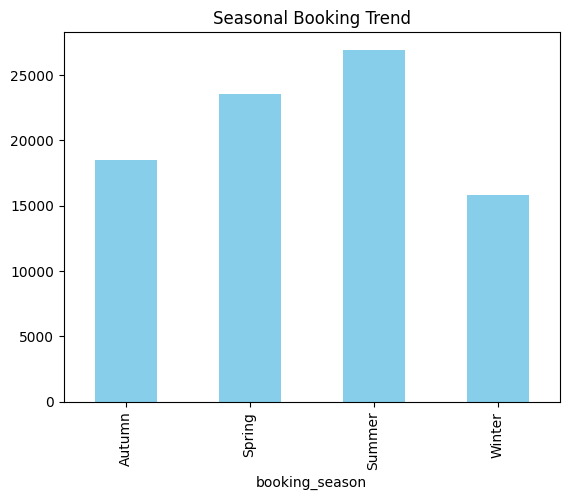

In [6]:
#Seasonal Booking Trend
season = df.groupby("booking_season").size()

season.plot(kind="bar",color="skyblue")
plt.title("Seasonal Booking Trend")
plt.show()

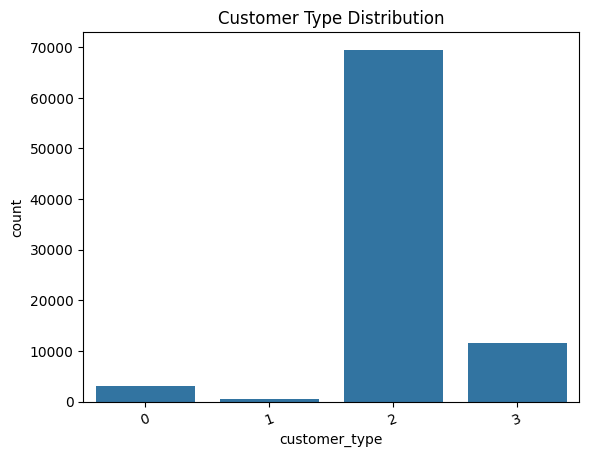

In [7]:
#Customer Type Distribution
sns.countplot(data=df,x="customer_type")
plt.title("Customer Type Distribution")
plt.xticks(rotation=20)
plt.show()

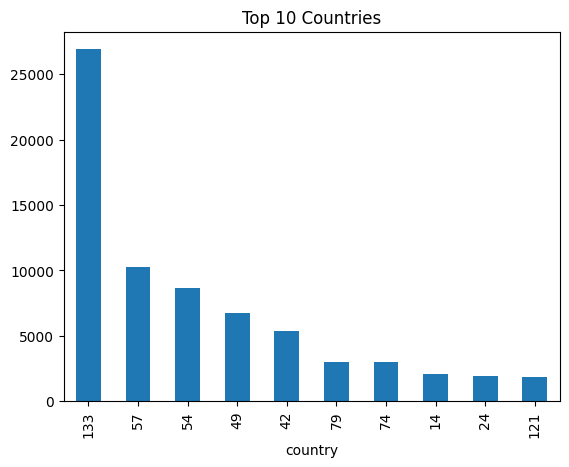

In [8]:
#Country-wise Bookings
top = df["country"].value_counts().head(10)

top.plot(kind="bar")
plt.title("Top 10 Countries")
plt.show()

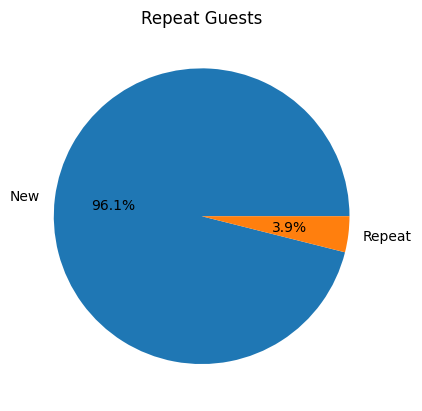

In [9]:
#Repeat Guests
repeat = df["is_repeated_guest"].value_counts()

plt.pie(
    repeat,
    labels=["New","Repeat"],
    autopct="%1.1f%%"
)

plt.title("Repeat Guests")
plt.show()

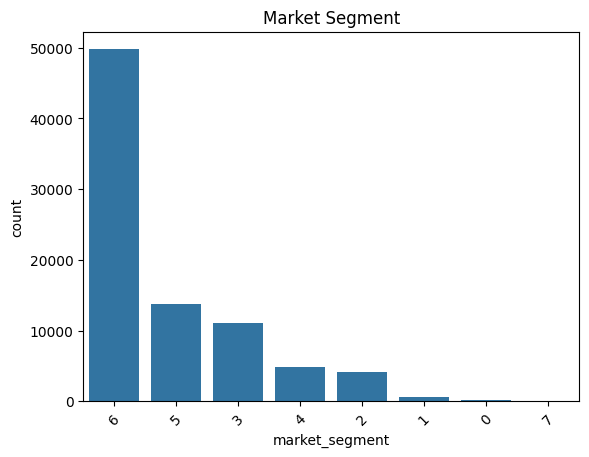

In [10]:
#Market Segment
sns.countplot(
    data=df,
    x="market_segment",
    order=df["market_segment"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Market Segment")
plt.show()

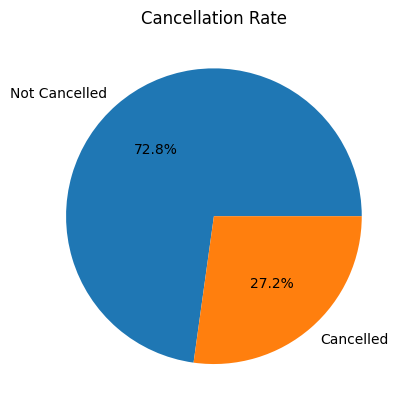

In [11]:
#Cancellation Rate
cancel = df["is_canceled"].value_counts()

plt.pie(
    cancel,
    labels=["Not Cancelled","Cancelled"],
    autopct="%1.1f%%"
)

plt.title("Cancellation Rate")
plt.show()

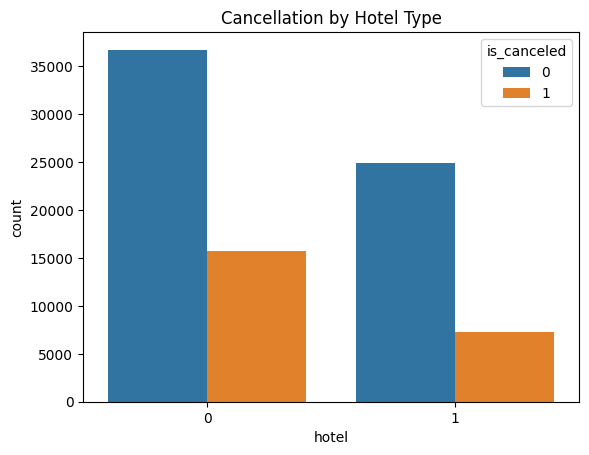

In [12]:
#Cancellation by Hotel
sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

plt.title("Cancellation by Hotel Type")
plt.show()

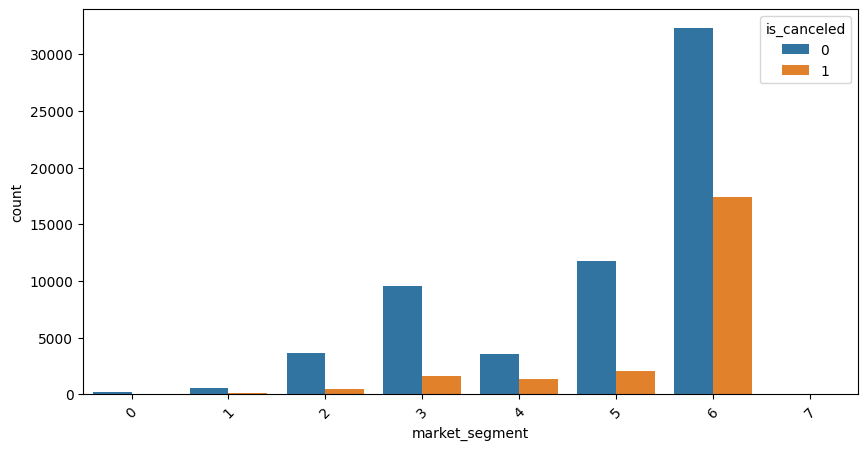

In [13]:
#Cancellation by Market Segment
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="market_segment",
    hue="is_canceled"
)

plt.xticks(rotation=45)

plt.show()

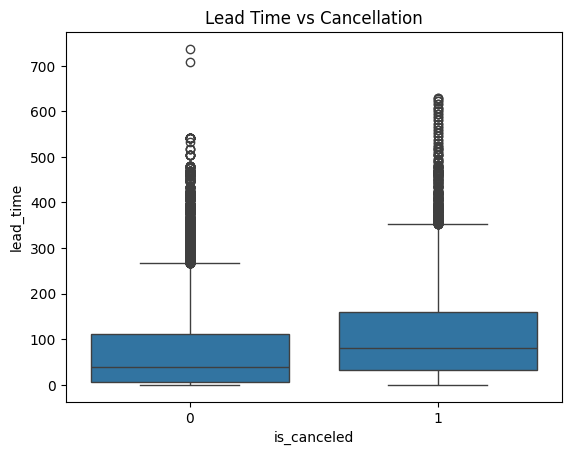

In [14]:
#Lead Time vs Cancellation
sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time"
)

plt.title("Lead Time vs Cancellation")
plt.show()

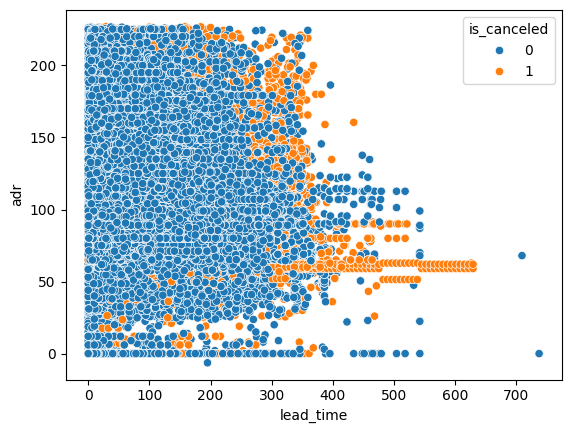

In [15]:
#Scatter Plot
sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    hue="is_canceled"
)

plt.show()

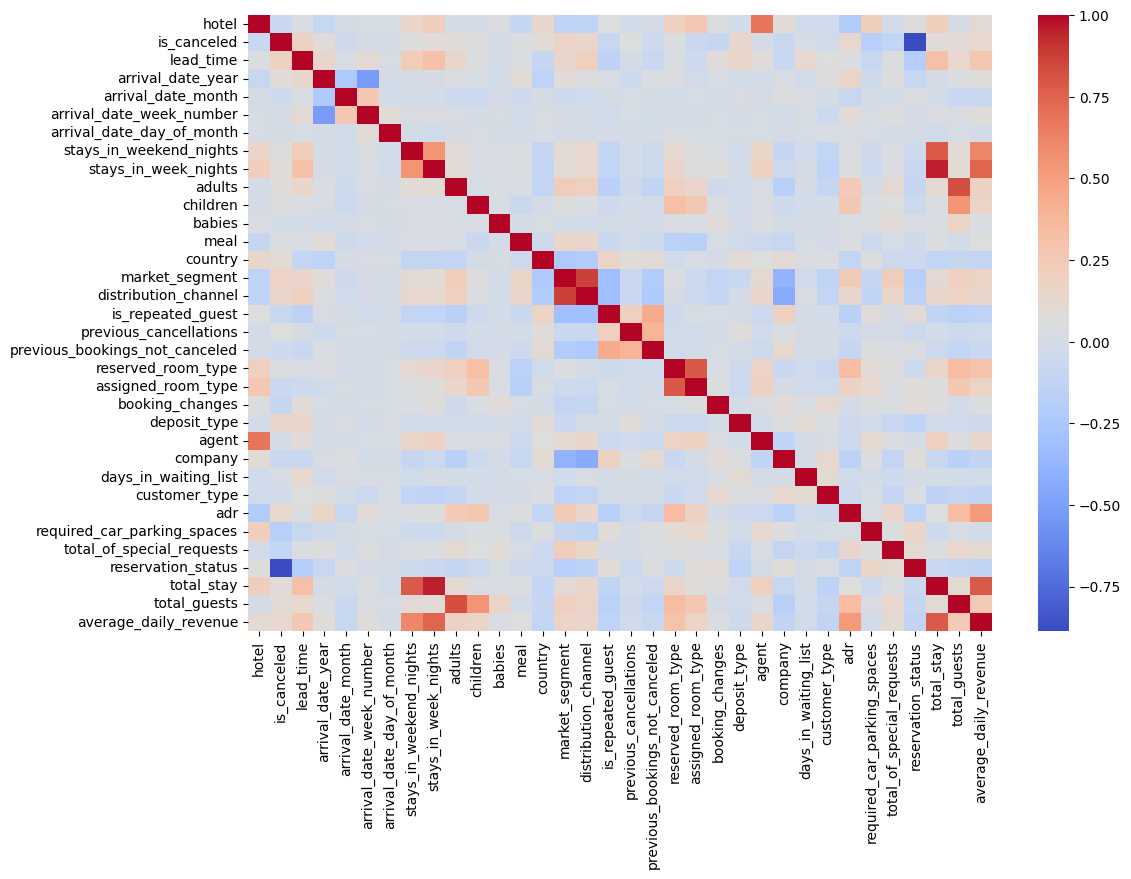

In [16]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    cmap="coolwarm"
)

plt.show()

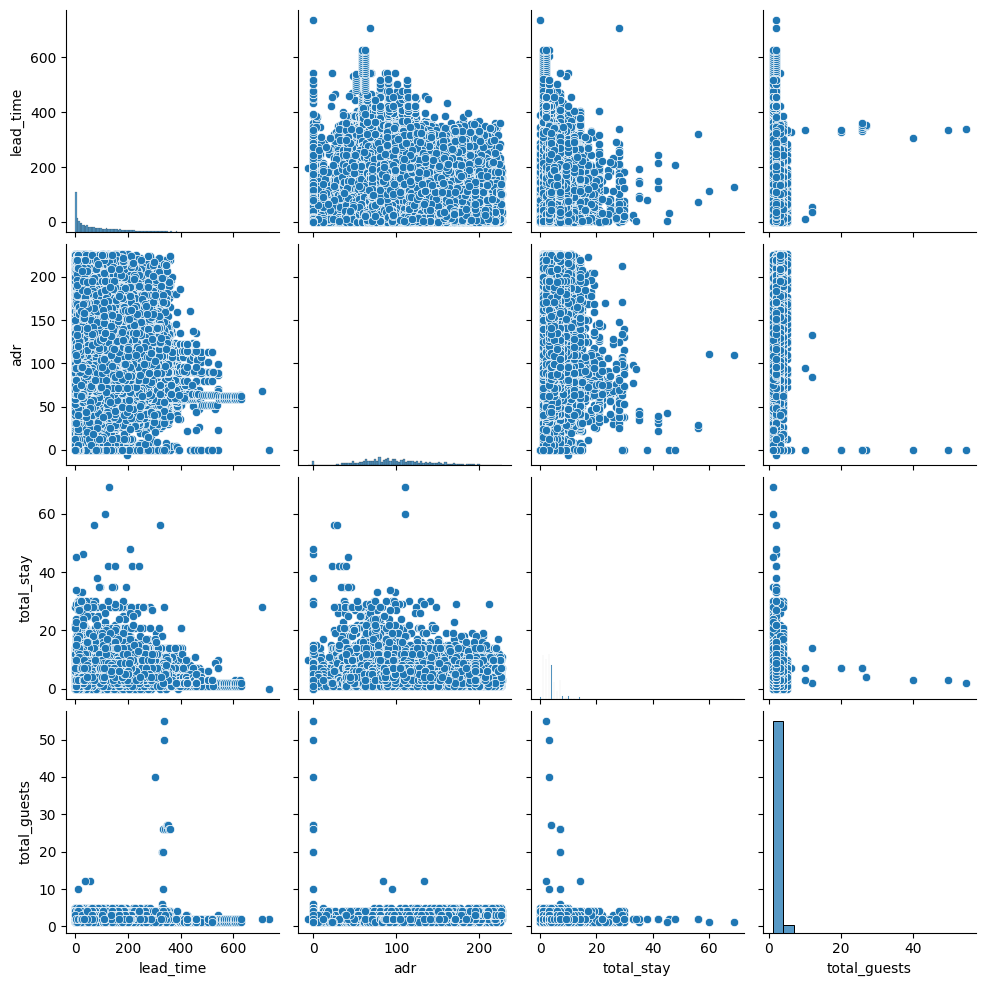

In [17]:
#Pair Plot
cols = [
    "lead_time",
    "adr",
    "total_stay",
    "total_guests"
]

sns.pairplot(df[cols])

plt.show()